___
# **BME 5710 project report**
## Instructor -- Rizwan Ahmad (ahmad.46@osu.edu)
## BME5710 -- Spring 2026

___
### Provide descriptive answers at `???` locations and insert figures or tables at `?content?`

___
### Write your name below.

Answer: Sathvik Kambam

___
### Write the names of your teammates

Answer: Morgan Shang and Mimi Ghosh

___
### (1.1 -- 5%) Provide a layout of your CNN

#### The layout should provide all the necessary details about the CNN architecture including number of channels, size of convolution kernels, activation functions, etc. For inspiration, see examples [here](https://www.geeksforgeeks.org/u-net-architecture-explained/), [here](https://www.researchgate.net/figure/The-architecture-of-Unet_fig2_334287825), and [here](https://www.researchgate.net/figure/Modified-U-net-network-architecture_fig2_356216368)

The CNN was a modified UNet layout. 

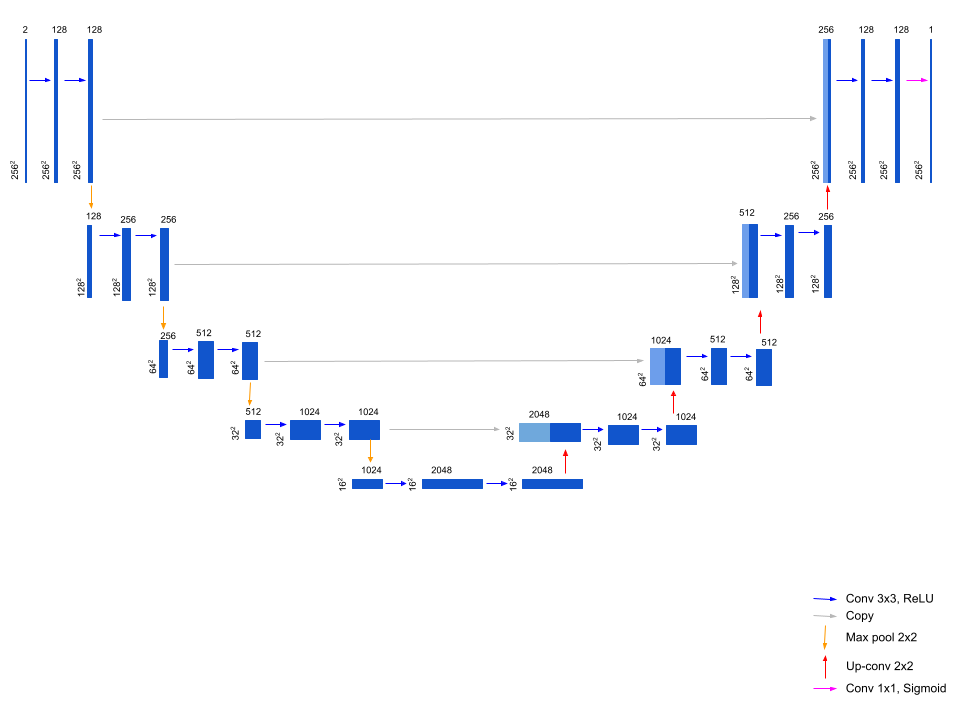

In [2]:
from IPython.display import Image, display
display(Image(filename = 'UNet_layout.png', width=1600, embed=True))

___
### (1.2 -- 1%) List *all* non-trivial features of your CNN and the training process. This may include use of dropout, learning rate scheduling, transfer learning, data augmentation, etc. Don't include items that are visible in the layout provided above.

Answer:  
Data augmentation was used by created 7 new images from each original image. One transformation is a horizontal flip. Then, the normal and flipped images, were rotated 90, 180, and 270 degrees.   
Batch normalization was used after the convolution in each layer.  
Dropout was used after the batch normalization in each layer, with a drop out rate of 10%.  
A learning rate scheduler was used. It starts at a learning rate of 1*10^-3, and it decreases by a factor of 0.5 if the validation loss doesn't improve after 5 epochs.  
The batch size used was 20 samples per batch.  
A mean squared error (MSE) loss was used.  
The Adam optimizer was used.  
A split of 0.9/0.1 was used for training/validation images.


___
### (2.1 -- 0.5%) Provide at least ten hyperparameters that you *could* optimize in your CNN design and training.

Answer:  
1. Batch size
1. Channel number of the first intermediate layer
1. Dropout rate
1. Factor at which learning rate decreases in scheduler
1. Number of epochs
1. Kernel size
1. Depth of UNet (aka how many max pooling/up-conv there should be)
1. Starting learning rate
1. Stride of up-conv/max pooling layers
1. Number of epochs
1. Validation to training ratio

___
### (2.2 -- 0.5%) Now, list the hyperparameters that you *have* optimized.

Answer: 
1. Number of epochs
1. Starting learning rate
1. Channel number

___
### (2.3 -- 0.5%) Describe your strategy/approach for optimizing hyperparameters.

Answer:  
The number of epochs was optimized by storing the currently best model from training as the epochs progress. So, as long as the epoch period is long enough, then the best model will still be stored no matter how many epochs there are. By trial and error, the number of epoch needed was found to be at least 180.  
The starting learning rates and channel numbers were optimized by modifying reasonable values. For example, the channel number was found by doubling the standard 64 channels and seeing if it worked better. The starting learning rate was reduced if the model couldn't be trained, and was increased again when additional features like batch normalization and dropout were added.  

___
### (2.4 -- 0.5%) What loss function did you use? Express the loss function mathematically.

Answer:  
The loss function used was the standard mean squared error loss (MSE loss). $ \mathcal{L} = \frac{1}{m}\sum_{i=1}^m(\hat{y}^{(i)} - y^{(i)})^2 $

___
### (2.5 -- 1%) Calculate the number of learnable parameters in your final CNN. How does that number compare with the number of training samples? Is your network overfitting or underfitting and how did you arrive at that conclusion? Explain that in the context of loss vs. epoch and/or performance metric vs. epoch curve for training and validation fold.

Answer: There are a lotal of 124,120,321 learneable parameters in the final CNN. This number is much higher than the number of training samples, which is 1800 samples. The network is likely slightly overfitting, since there were times when the training metric increased when the validation metric was stagnant. However, the dropout kept the training loss below the validation loss, and both eventually slowly decreased together.

___
### (3.1 -- 5%) Insert (or draw using Markdown) a table that provides average values of PSNR, SSIM, and PSNR + 50×SSIM for (i) the trivial inpainting baseline (replace missing pixels with zeros), (ii) images inpainted with the single-layer CNN from `demo_inpainting.ipynb`, and (iii) images inpainted with your CNN. Include metrics from training, validation, and test folds. Note that for the test fold you cannot compute PSNR and SSIM separately as you don't have access to the ground truth. For this fold, report metrics from Kaggle.

|Trivial     | PSNR        | SSIM        |PSNR + 50*SSIM |       
|:---        |   :----:    |    :----:   |     :---:     |  
|Training    | 15.585      | 0.176       | 24.373        |  
|Validation  | 15.837      | 0.187       | 25.194        |  
|Testing     |     -       |      -      | 23.625        |  
 ___
|1-layer CNN | PSNR        | SSIM        |PSNR + 50*SSIM |       
|:---        | :----:      |    :----:   |     :---:     |  
|Training    | 20.818      | 0.492       | 45.441        |  
|Validation  | 20.687      | 0.490       | 45.163        |  
|Testing     |     -       |      -      | 47.176        |  
___
|Final CNN   | PSNR        | SSIM        |PSNR + 50*SSIM |       
|   :---     | :----:      |    :----:   |     :---:     |  
|Training    | 32.650      | 0.928       | 79.052        |  
|Validation  | 32.945      | 0.942       | 80.032        |  
|Testing     |     -       |      -      | 80.244        |  

___
### (3.2 -- 1%) When it comes to comparing images, what does SSIM capture that PSNR does not?

Answer: SSIM captures how similar the true image and the prediction is in terms of structure, while PSNR only captures how clear prediction is and how much noise it has compared to the true image. The PSNR isn't able to see whether they have similar structures, only the noise ratios.

___
### (4.1 -- 4%) Display a figure where the first row (from left to right) shows (i) an input image without masking, (ii) the masked input image, (iii) the image inpainted with the single-layer CNN from `demo_inpainting.ipynb`, and (iv) the image inpainted with your CNN, and the second row shows the corresponding error maps after 3-fold amplification. For this figure, you may select any image from the validation dataset.

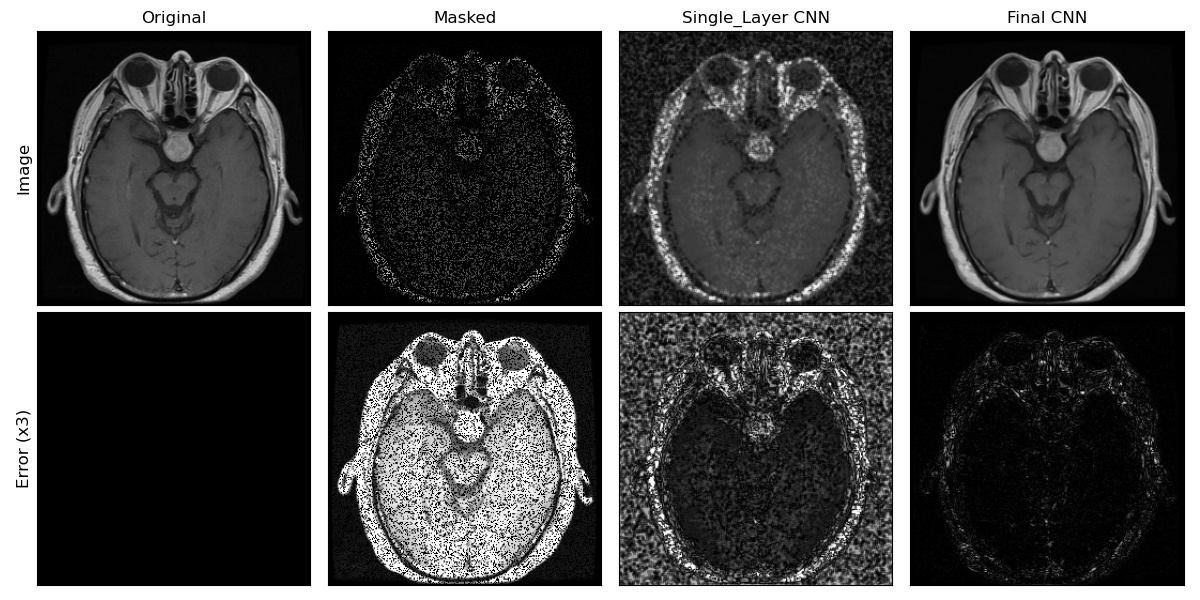

In [3]:
display(Image(filename = 'Network_Comparison.png', width=1600, embed=True))

___
### (4.2 -- 1%) From (4.1), subjectively identify which image features are well-recovered by your CNN (e.g., smooth regions, edges, fine structures) and which are not. Additionally, describe how you could further improve the performance of your model if given more time and resources.

Answer: ???

___
### (4.3 -- 0%) Describe the extent to which you used AI to complete this project. There is no penalty for using or not using AI. This information helps the instructor understand how AI tools were used in the learning process.

Answer: ???